<a href="https://colab.research.google.com/github/mkromah/gbm-multisource-biomarker-project/blob/main/Note_Book%2006_model_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Notebook 06 — Model Comparison

## Purpose
This notebook compares multiple machine learning models for distinguishing
glioblastoma (GBM) from lower-grade glioma (LGG) using the biomarker panels
identified in the discovery and validation workflow.

In [ ]:
# ============================================================
# Shared project configuration
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# Project paths and imports
# ============================================================

import os
import numpy as np
import pandas as pd

PROJECT_NAME = "Glioma_ML_Biomarker_Project"
BASE_DIR = f"/content/drive/MyDrive/{PROJECT_NAME}"

DATA_DIR = f"{BASE_DIR}/data"
RAW_DIR = f"{DATA_DIR}/raw"
PROCESSED_DIR = f"{DATA_DIR}/processed"

RESULTS_DIR = f"{BASE_DIR}/results"
FIGURES_DIR = f"{RESULTS_DIR}/figures"
TABLES_DIR = f"{RESULTS_DIR}/tables"
MODELS_DIR = f"{BASE_DIR}/models"

print("Project root loaded:")
print(BASE_DIR)

Project root loaded:
/content/drive/MyDrive/Glioma_ML_Biomarker_Project


In [ ]:
# ============================================================
# Step 2: Inspect saved result files
# ============================================================

print("Files in RESULTS_DIR:\n")
for f in sorted(os.listdir(RESULTS_DIR)):
    print(f)

Files in RESULTS_DIR:

figures
final_cross_cohort_biomarkers.csv
tables
xena_gene_importance_ranking.csv


In [ ]:
# ============================================================
# Step 3: Load final biomarker panel
# ============================================================

final_biomarker_path = f"{RESULTS_DIR}/final_cross_cohort_biomarkers.csv"

final_biomarkers = pd.read_csv(final_biomarker_path)

print("Final biomarker panel loaded successfully.")
print("Shape:", final_biomarkers.shape)

print("\nBiomarker genes:")
print(final_biomarkers["gene"].tolist())

Final biomarker panel loaded successfully.
Shape: (21, 2)

Biomarker genes:
['MMP9', 'LINC00152', 'ESM1', 'CLIC1', 'SERPINH1', 'AGAP2-AS1', 'KCNB1', 'ANXA2', 'LOX', 'CCDC109B', 'EMP3', 'PLEK2', 'SH2D4A', 'TUBA1C', 'FN1', 'TNFRSF12A', 'RAB34', 'CA9', 'TAGLN2', 'GDF15', 'SPAG4']


In [ ]:
# ============================================================
# Step 4: Inspect XENA raw-data files
# ============================================================

XENA_DIR = f"{RAW_DIR}/XENA"

print("XENA_DIR:", XENA_DIR)
print("\nFiles in XENA folder:\n")

for f in sorted(os.listdir(XENA_DIR)):
    print(f)

XENA_DIR: /content/drive/MyDrive/Glioma_ML_Biomarker_Project/data/raw/XENA

Files in XENA folder:

TcgaTargetGTEX_phenotype.txt.gz
TcgaTargetGtex_rsem_gene_tpm.gz
probeMap_gencode.v23.annotation.gene.probemap


In [ ]:
# ============================================================
# Step 5: Load XENA phenotype table
# ============================================================

xena_pheno_path = f"{XENA_DIR}/TcgaTargetGTEX_phenotype.txt.gz"

xena_pheno = pd.read_csv(
    xena_pheno_path,
    sep="\t",
    compression="gzip",
    encoding="latin1"
)

print("XENA phenotype table loaded successfully.")
print("Shape:", xena_pheno.shape)

xena_pheno.head()

XENA phenotype table loaded successfully.
Shape: (19131, 7)


,sample,detailed_category,primary disease or tissue,_primary_site,_sample_type,_gender,_study
0,TCGA-V4-A9EE-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
1,TCGA-VD-AA8N-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
2,TCGA-V4-A9EI-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
3,TCGA-VD-AA8O-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA
4,TCGA-WC-A888-01,Uveal Melanoma,Uveal Melanoma,Eye,Primary Tumor,Male,TCGA


In [ ]:
# ============================================================
# Step 6: Extract TCGA glioma tumor samples
# ============================================================

glioma_categories = ["Glioblastoma Multiforme", "Brain Lower Grade Glioma"]

tcga_glioma_meta = xena_pheno[
    xena_pheno["detailed_category"].isin(glioma_categories)
].copy()

tcga_glioma_meta = tcga_glioma_meta[
    tcga_glioma_meta["_sample_type"] == "Primary Tumor"
].copy()

print("TCGA glioma tumor samples extracted.")
print("Shape:", tcga_glioma_meta.shape)

print("\nLabel distribution:")
print(tcga_glioma_meta["detailed_category"].value_counts())

TCGA glioma tumor samples extracted.
Shape: (662, 7)

Label distribution:
detailed_category
Brain Lower Grade Glioma    509
Glioblastoma Multiforme     153
Name: count, dtype: int64


In [ ]:
# ============================================================
# Step 7: Load TCGA gene expression matrix
# ============================================================

expr_path = f"{XENA_DIR}/TcgaTargetGtex_rsem_gene_tpm.gz"

tcga_expr = pd.read_csv(
    expr_path,
    sep="\t",
    compression="gzip"
)

print("TCGA expression matrix loaded.")
print("Shape:", tcga_expr.shape)

tcga_expr.head()

TCGA expression matrix loaded.
Shape: (60498, 19132)


,sample,GTEX-S4Q7-0003-SM-3NM8M,TCGA-19-1787-01,TCGA-S9-A7J2-01,GTEX-QV31-1626-SM-2S1QC,TCGA-G3-A3CH-11,TCGA-B5-A5OE-01,GTEX-13QIC-0011-R1a-SM-5O9CJ,TCGA-B2-5641-11,GTEX-ZPCL-0126-SM-4WWC8,...,TCGA-FI-A2EY-01,TCGA-55-6985-11,TCGA-EJ-5527-01,TCGA-G3-A25X-01,TCGA-24-2254-01,GTEX-11ZTS-3326-SM-5LU9Y,GTEX-VJYA-0726-SM-4KL1T,GTEX-ZA64-2126-SM-5Q5A8,GTEX-Q2AG-2826-SM-2HMJQ,GTEX-XV7Q-0426-SM-4BRVN
0,ENSG00000242268.2,-3.4580,-9.9658,0.2998,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,...,-4.0350,-2.0529,-9.9658,-9.9658,-1.9379,1.5165,-9.9658,-2.3884,0.0440,-3.3076
1,ENSG00000259041.1,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,...,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658
2,ENSG00000270112.3,-3.6259,-3.8160,-3.0469,-2.1779,-9.9658,-9.9658,-1.8314,-2.4659,-9.9658,...,-3.1714,-4.2934,-9.9658,-9.9658,-5.5735,-2.9324,-9.9658,-9.9658,2.5852,-3.0469
3,ENSG00000167578.16,4.5988,5.2998,4.8881,4.6294,3.5572,5.0858,6.4989,4.6317,5.5358,...,4.7253,5.4206,4.4771,5.2627,5.0760,6.0809,4.7410,5.3212,5.8110,5.9132
4,ENSG00000278814.1,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,...,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658


In [ ]:
# ============================================================
# Step 8: Load XENA gene annotation map
# ============================================================

gene_map_path = f"{XENA_DIR}/probeMap_gencode.v23.annotation.gene.probemap"

gene_map = pd.read_csv(
    gene_map_path,
    sep="\t"
)

print("Gene annotation map loaded successfully.")
print("Shape:", gene_map.shape)

gene_map.head()

Gene annotation map loaded successfully.
Shape: (60498, 6)


,id,gene,chrom,chromStart,chromEnd,strand
0,ENSG00000223972.5,DDX11L1,chr1,11869,14409,+
1,ENSG00000227232.5,WASH7P,chr1,14404,29570,-
2,ENSG00000278267.1,MIR6859-1,chr1,17369,17436,-
3,ENSG00000243485.3,RP11-34P13.3,chr1,29554,31109,+
4,ENSG00000274890.1,MIR1302-2,chr1,30366,30503,+


In [ ]:
# ============================================================
# Step 9: Map TCGA Ensembl IDs to gene symbols
# ============================================================

# Create clean Ensembl IDs without version numbers
tcga_expr = tcga_expr.copy()
tcga_expr["ensembl_id"] = tcga_expr["sample"].astype(str).str.split(".").str[0]

gene_map = gene_map.copy()
gene_map["ensembl_id"] = gene_map["id"].astype(str).str.split(".").str[0]

# Merge expression matrix with gene symbols
tcga_expr_annot = tcga_expr.merge(
    gene_map[["ensembl_id", "gene"]],
    on="ensembl_id",
    how="left"
)

print("TCGA expression mapped to gene symbols.")
print("Shape:", tcga_expr_annot.shape)

tcga_expr_annot[["sample", "ensembl_id", "gene"]].head()

TCGA expression mapped to gene symbols.
Shape: (60498, 19134)


,sample,ensembl_id,gene
0,ENSG00000242268.2,ENSG00000242268,RP11-368I23.2
1,ENSG00000259041.1,ENSG00000259041,RP11-167B3.1
2,ENSG00000270112.3,ENSG00000270112,RP11-742D12.2
3,ENSG00000167578.16,ENSG00000167578,RAB4B
4,ENSG00000278814.1,ENSG00000278814,AC104071.1


In [ ]:
# ============================================================
# Step 10: Filter TCGA matrix to final biomarker genes
# ============================================================

biomarker_genes = final_biomarkers["gene"].dropna().unique().tolist()

tcga_biomarker_expr = tcga_expr_annot[
    tcga_expr_annot["gene"].isin(biomarker_genes)
].copy()

print("TCGA biomarker expression extracted.")
print("Shape:", tcga_biomarker_expr.shape)

print("\nExtracted genes:")
print(sorted(tcga_biomarker_expr["gene"].dropna().unique().tolist()))

TCGA biomarker expression extracted.
Shape: (21, 19134)

Extracted genes:
['AGAP2-AS1', 'ANXA2', 'CA9', 'CCDC109B', 'CLIC1', 'EMP3', 'ESM1', 'FN1', 'GDF15', 'KCNB1', 'LINC00152', 'LOX', 'MMP9', 'PLEK2', 'RAB34', 'SERPINH1', 'SH2D4A', 'SPAG4', 'TAGLN2', 'TNFRSF12A', 'TUBA1C']


In [ ]:
# ============================================================
# Step 11: Filter expression matrix to TCGA glioma samples
# ============================================================

glioma_samples = tcga_glioma_meta["sample"].tolist()

# keep only these columns
cols_to_keep = ["gene"] + glioma_samples

tcga_biomarker_expr = tcga_biomarker_expr[cols_to_keep]

print("TCGA glioma biomarker matrix created.")
print("Shape:", tcga_biomarker_expr.shape)

tcga_biomarker_expr.head()

TCGA glioma biomarker matrix created.
Shape: (21, 663)


,gene,TCGA-41-2571-01,TCGA-16-0846-01,TCGA-06-2559-01,TCGA-32-2634-01,TCGA-06-2562-01,TCGA-32-2632-01,TCGA-02-0047-01,TCGA-06-2557-01,TCGA-76-4925-01,...,TCGA-FG-6691-01,TCGA-QH-A6XA-01,TCGA-HT-A74L-01,TCGA-S9-A6U1-01,TCGA-FG-A70Y-01,TCGA-HT-7877-01,TCGA-HT-A61A-01,TCGA-P5-A5EW-01,TCGA-HT-7482-01,TCGA-R8-A6YH-01
140,ESM1,0.0014,-3.8160,3.0654,4.2056,4.0383,-1.1172,5.0488,1.0151,3.9992,...,-0.5543,-6.5064,-2.8262,-4.2934,-6.5064,-2.5479,-2.6349,-3.6259,-3.8160,-2.2447
2415,TUBA1C,6.0171,7.1326,7.8388,7.8243,8.8241,8.0840,6.7860,6.7111,8.8759,...,5.5280,4.0901,5.3930,4.0515,4.3772,3.6289,4.4027,4.4297,4.7345,4.7038
14995,SPAG4,3.7182,0.5170,3.9289,3.9147,3.4817,0.5763,2.7551,1.1641,5.0653,...,-1.2142,-1.1488,-1.7809,-1.3921,-1.0559,-0.8339,0.8164,-1.5522,-2.5479,-2.3884
17670,KCNB1,0.9268,1.3225,1.6187,2.3193,0.6050,-0.7588,1.7185,-0.7834,1.8160,...,4.7746,3.0463,4.0100,3.7215,3.1458,3.8660,3.6612,3.9847,3.1442,3.5899
19141,PLEK2,-0.3566,1.1706,2.4727,2.3704,2.9729,1.7786,1.3623,0.1903,0.9191,...,-2.3884,-2.8262,-2.2447,-3.8160,-1.1811,-2.1779,-0.0130,-4.0350,-4.2934,-3.3076


In [ ]:
# ============================================================
# Step 12: Transpose TCGA biomarker matrix and attach labels
# ============================================================

# Transpose to sample × gene format
tcga_ml = tcga_biomarker_expr.set_index("gene").T

# Create label map
label_map = tcga_glioma_meta.set_index("sample")["detailed_category"].map({
    "Brain Lower Grade Glioma": 0,
    "Glioblastoma Multiforme": 1
})

# Attach labels
tcga_ml = tcga_ml.copy()
tcga_ml.loc[:, "tumor_label"] = tcga_ml.index.map(label_map)

print("TCGA ML matrix created successfully.")
print("Shape:", tcga_ml.shape)

print("\nLabel distribution:")
print(tcga_ml["tumor_label"].value_counts())

tcga_ml.head()

TCGA ML matrix created successfully.
Shape: (662, 22)

Label distribution:
tumor_label
0    509
1    153
Name: count, dtype: int64


gene,ESM1,TUBA1C,SPAG4,KCNB1,PLEK2,FN1,ANXA2,CA9,AGAP2-AS1,CLIC1,...,LOX,SERPINH1,SH2D4A,LINC00152,TNFRSF12A,RAB34,TAGLN2,MMP9,EMP3,tumor_label
TCGA-41-2571-01,0.0014,6.0171,3.7182,0.9268,-0.3566,7.4233,7.1342,6.3920,3.7345,6.1316,...,3.2450,4.4996,-0.5756,3.8075,5.3872,3.2343,7.0033,4.1852,5.4519,1
TCGA-16-0846-01,-3.8160,7.1326,0.5170,1.3225,1.1706,7.7859,7.6859,0.1388,7.6964,7.7319,...,-0.2671,5.0462,-0.2498,4.6106,6.3194,4.8876,8.3597,-1.7809,7.5918,1
TCGA-06-2559-01,3.0654,7.8388,3.9289,1.6187,2.4727,9.4608,8.1376,5.9383,7.5160,8.5748,...,4.7709,7.3525,1.8840,7.2727,6.4824,5.7498,9.0174,5.6834,7.3116,1
TCGA-32-2634-01,4.2056,7.8243,3.9147,2.3193,2.3704,9.1199,8.1703,4.5479,4.2025,7.7131,...,5.1871,6.5606,2.5087,5.4916,5.8395,5.9334,8.2965,5.2750,7.6814,1
TCGA-06-2562-01,4.0383,8.8241,3.4817,0.6050,2.9729,9.9331,10.3359,3.3633,2.9674,8.9592,...,6.8101,7.5760,2.8137,7.7946,8.9513,6.8463,9.2915,5.6174,8.2896,1


In [ ]:
# ============================================================
# Step 13: Separate features and labels
# ============================================================

X_tcga = tcga_ml.drop(columns=["tumor_label"])
y_tcga = tcga_ml["tumor_label"]

print("Feature matrix shape:", X_tcga.shape)
print("Label vector shape:", y_tcga.shape)

print("\nLabel distribution:")
print(y_tcga.value_counts())

Feature matrix shape: (662, 21)
Label vector shape: (662,)

Label distribution:
tumor_label
0    509
1    153
Name: count, dtype: int64


In [ ]:
# ============================================================
# Step 14: Train-test split
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tcga,
    y_tcga,
    test_size=0.2,
    stratify=y_tcga,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTrain label distribution:")
print(y_train.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())

Training set: (529, 21)
Test set: (133, 21)

Train label distribution:
tumor_label
0    407
1    122
Name: count, dtype: int64

Test label distribution:
tumor_label
0    102
1     31
Name: count, dtype: int64


In [ ]:
# ============================================================
# Step 15: Logistic Regression model
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

log_model = LogisticRegression(
    max_iter=1000,
    solver="liblinear"
)

log_model.fit(X_train, y_train)

# Predictions
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

# Metrics
acc_log = accuracy_score(y_test, y_pred_log)
auc_log = roc_auc_score(y_test, y_prob_log)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy:", round(acc_log,4))
print("ROC-AUC:", round(auc_log,4))

Logistic Regression Results
---------------------------
Accuracy: 0.9098
ROC-AUC: 0.9497


In [ ]:
# ============================================================
# Step 16: Random Forest model
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# Metrics
acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("---------------------")
print("Accuracy:", round(acc_rf,4))
print("ROC-AUC:", round(auc_rf,4))

Random Forest Results
---------------------
Accuracy: 0.9248
ROC-AUC: 0.9649


In [ ]:
# ============================================================
# Step 17: XGBoost model
# ============================================================

# install XGBoost if not already installed
!pip install xgboost

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

# Metrics
acc_xgb = accuracy_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Results")
print("----------------")
print("Accuracy:", round(acc_xgb,4))
print("ROC-AUC:", round(auc_xgb,4))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:14:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Results
----------------
Accuracy: 0.9173
ROC-AUC: 0.9481


In [ ]:
# ============================================================
# Step 18: Model comparison
# ============================================================

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [acc_log, acc_rf, acc_xgb],
    "ROC_AUC": [auc_log, auc_rf, auc_xgb]
})

results = results.sort_values(by="ROC_AUC", ascending=False)

print("Model Comparison")
display(results)

Model Comparison


,Model,Accuracy,ROC_AUC
1,Random Forest,0.924812,0.964896
0,Logistic Regression,0.909774,0.949715
2,XGBoost,0.917293,0.948134


In [ ]:
# ============================================================
# Step 19: Save model comparison table
# ============================================================

os.makedirs(TABLES_DIR, exist_ok=True)

results.to_csv(
    f"{TABLES_DIR}/model_comparison.csv",
    index=False
)

print("Model comparison table saved successfully.")

Model comparison table saved successfully.


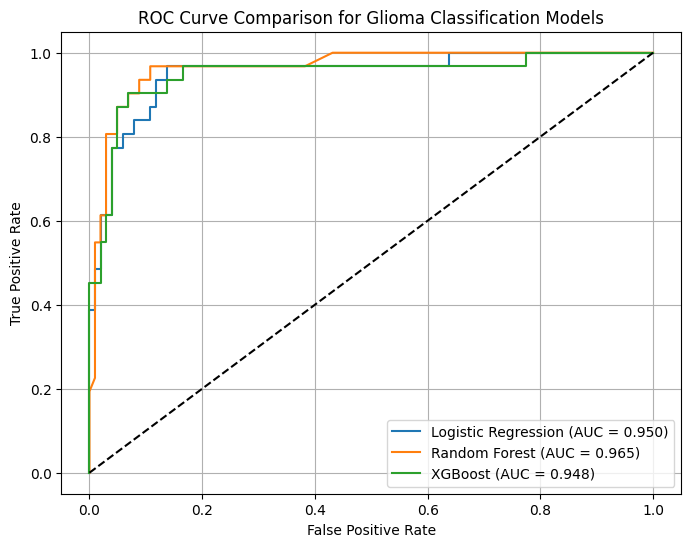

In [ ]:
# ============================================================
# Step 20: ROC comparison plot
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")

plt.plot([0,1], [0,1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison for Glioma Classification Models")
plt.legend()
plt.grid()

os.makedirs(FIGURES_DIR, exist_ok=True)
plt.savefig(f"{FIGURES_DIR}/model_comparison_ROC.png", dpi=300, bbox_inches="tight")
plt.show()